# **Stochastic Interest Rate Modelling and Prediction**
### **Cox-Ingersoll-Ross (CIR) Calibration & Yield Curve Reconstruction**

**Finance Club, IIT Roorkee: Open Projects 2026**  
**Name:** Manish Kumar Gupta

---

## **1. Summary**

Interest rates are the fundamental building blocks of the global financial system. They dictate the pricing of bonds, the valuation of derivatives, and the risk management strategies of institutional portfolios. Yet interest rates are not static; they evolve over time in a complex, seemingly random manner that resists simple forecasting. To capture this evolution, quantitative analysts rely on advanced mathematical frameworks rooted in stochastic calculus.

This project implements a complete, rigorous quantitative pipeline to:
1. **Preprocess and clean** a daily historical yield curve dataset containing trailing-space headers, non-trading day gaps, and noisy market spikes.
2. **Implement and calibrate** the **Cox-Ingersoll-Ross (CIR)** stochastic short-rate model from first principles.
3. **Compare three calibration methodologies**: Ordinary Least Squares (OLS), Maximum Likelihood Estimation (MLE), and Cross-Sectional Calibration, discussing their statistical and financial trade-offs under the physical measure $\mathbb{P}$ and risk-neutral measure $\mathbb{Q}$.
4. **Reconstruct the entire out-of-sample yield curve** using **ONLY the 3-Month (3M) rate** as the proxy for the instantaneous short rate $r_t$, evaluating performance against held-out actuals.
5. **Implement and backtest two advanced extensions**: the **Shifted CIR++ Model** with validation-based chronological shrinkage to mitigate overfitting under interest rate regime shifts, and the **Additive Two-Factor CIR Model**.
6. **Compare with Machine Learning Benchmark Models**: Lasso, Ridge, ElasticNet, K-Nearest Neighbors, XGBoost, and Gradient Boosting Regressors.
7. **Perform a detailed critical analysis** answering key quantitative finance questions regarding calibration sensitivity, Feller condition breakdowns, shock persistence, and multi-factor estimation challenges.

---

### **Macroeconomic Regime Shift Context**

A critical challenge of this project is the **profound regime shift** between the training and testing periods:
- **Training Period (2016–2024)**: Dominated by a low-rate environment and an **upward-sloping yield curve** (3M rate mean: $1.67\%$, 2Y rate mean: $1.81\%$, 10Y rate mean: $2.02\%$).
- **Testing Period (2024–2026)**: Dominated by a high-rate environment and an **inverted yield curve** (3M rate mean: $3.04\%$, 2Y rate mean: $2.87\%$, where yields decrease as maturity increases).

We will show how our risk-neutral MLE calibration captures this structural change, enabling our base model to naturally predict inverted yield curves out-of-sample and achieve an **out-of-sample $R^2$ of $\approx 0.947$** on held-out tenors (6M–2Y; 3M input only), far exceeding the $0.85$ project benchmark. The CIR model can also produce theoretical yield estimates for longer horizons ranging from 5 to 30 years. These longer-dated maturities, however, are not included in the labels provided in `test_data.csv`.


## **2. Google Colab Environment Auto-Setup & Imports**

This block imports the required scientific libraries, sets a visual theme for Matplotlib/Seaborn, and automatically downloads the necessary datasets from Google Drive if they are not already present in the working directory.


In [1]:
import os
import urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import ncx2 # non-central chi-square distribution (for mle)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Setting visualization theme
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.facecolor': '#fbfbfd',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#d6d9e0',
    'axes.labelcolor': '#20242c',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.color': '#3b3f49',
    'ytick.color': '#3b3f49',
    'grid.color': '#e7e9ef',
    'grid.linestyle': '-',
    'grid.linewidth': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.92,
    'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#d6d9e0',
    'font.family': 'sans-serif',
    'figure.dpi': 150
})

# Color Palette definition
PALETTE = {
    'actual': '#111827',     # Elegant Dark Charcoal
    'predicted': '#2563EB',  # Premium Cobalt Blue
    'accent': '#DC2626',     # Vibrant Crimson
    'highlight': '#7C3AED',  # Regal Purple
    'success': '#059669',    # Soft Emerald Green
    'fill': '#93C5FD',       # Soft Blue Fill
    'muted': '#9CA3AF'       # Cool Grey
}

# Automatic Dataset Download from Google Drive
file_ids = {
    'train_data.csv': '1FMCr1mxYfSuXEhYfy-EzTNCdjXN4vAEn',
    'test_data.csv': '1nXhHWJygVYFA6gtRhANiiEALmeNojZ_H',
    'test_data_3M.csv': '1df7pvK7MW_tMGM5NJCg9R2kl-YSOFtBa'
}

def download_from_drive(file_id, dest_filename):
    url = f'https://drive.google.com/uc?export=download&id={file_id}'
    if not os.path.exists(dest_filename):
        print(f'Downloading {dest_filename} from Google Drive...')
        try:
            urllib.request.urlretrieve(url, dest_filename)
            print(f'Successfully downloaded {dest_filename}.')
        except Exception as e:
            print(f'Failed to download {dest_filename}: {e}')
    else:
        print(f'{dest_filename} already exists. Skipping download.')

for filename, fid in file_ids.items():
    download_from_drive(fid, filename)


train_data.csv already exists. Skipping download.
test_data.csv already exists. Skipping download.
test_data_3M.csv already exists. Skipping download.


## **3. Data Preprocessing & Cleaning**

Raw financial datasets are rarely ready for mathematical modelling. Gaps due to non-trading days, incorrect date sorting, and database feed anomalies (spikes) must be resolved.

We implement a clean, modular preprocessing function that:
1. **Strips column headers** to handle trailing/leading spaces (e.g. `' ZC025YR'`).
2. **Sorts chronologically** on observed trade dates.
3. **Removes single-day spike reversals first** (on the *sparse* series), so a bad print is not duplicated by later gap-filling.
4. **Reindexes** to a standard business-day calendar (`'B'`).
5. **Fills calendar gaps** with **time-based linear interpolation** (not `ffill()`), so a spike is not copied into a holiday slot (e.g. Veterans Day after 2020-11-10).
6. **Back-fills** only leading NaNs at the series start using the first valid observation (no future leak).


In [2]:
def apply_spike_reversal_filter(y, threshold_mult=4.0):
    """Smooth single-day spike reversals on a 1D yield series (uses adjacent observations)."""
    y = np.asarray(y, dtype=float).copy()
    n = len(y)
    if n < 3:
        return y, 0

    diffs = np.diff(y)
    std_diff = np.std(diffs)
    if std_diff == 0:
        return y, 0

    threshold = threshold_mult * std_diff
    corrected = 0
    for i in range(1, n - 1):
        diff_prev = y[i] - y[i - 1]
        diff_next = y[i] - y[i + 1]
        if (abs(diff_prev) > threshold and abs(diff_next) > threshold
                and np.sign(diff_prev) == np.sign(diff_next)):
            y[i] = 0.5 * (y[i - 1] + y[i + 1])
            corrected += 1
    return y, corrected


def preprocess_yield_data(file_path, label='Dataset'):
    # 1. Load CSV
    df = pd.read_csv(file_path)

    # 2. Strip whitespaces from column headers
    df.columns = df.columns.str.strip()

    # 3. Format dates and sort chronologically
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    raw_df = df.copy()
    yield_cols = [c for c in df.columns if c != 'Date']

    # 4. Spike filter on OBSERVED dates only (before reindex/ffill duplicates spikes)
    df = df.set_index('Date').sort_index()
    outliers_corrected = 0
    for col in yield_cols:
        y, n_fix = apply_spike_reversal_filter(df[col].values)
        df[col] = y
        outliers_corrected += n_fix

    # 5. Reindex to business days and fill gaps without forward-propagating spikes
    all_bdays = pd.date_range(start=df.index.min(), end=df.index.max(), freq='B')
    df_reindexed = df.reindex(all_bdays)
    df_reindexed.index.name = 'Date'

    # Time interpolation across short calendar gaps (holiday between two prints)
    df_filled = df_reindexed.interpolate(method='time', limit=5, limit_direction='both')

    # Leading NaNs only: extend first valid observation backward (no future leak)
    for col in yield_cols:
        if df_filled[col].isna().any() and df_filled[col].notna().any():
            df_filled[col] = df_filled[col].fillna(df_filled[col].dropna().iloc[0])

    cleaned_df = df_filled.reset_index()

    print(f'{label} Preprocessed successfully:')
    print(f'  - Rows: {len(raw_df)} -> {len(cleaned_df)} (aligned to business days)')
    print(f'  - Outliers smoothed (pre-reindex): {outliers_corrected}')
    return raw_df, cleaned_df

# Preprocess all three datasets
train_raw, train_clean = preprocess_yield_data('train_data.csv', 'Training Set')
test_raw, test_clean = preprocess_yield_data('test_data.csv', 'Test Set')
test_3m_raw, test_3m_clean = preprocess_yield_data('test_data_3M.csv', 'Test 3M Proxy Set')


Training Set Preprocessed successfully:
  - Rows: 1976 -> 2072 (aligned to business days)
  - Outliers smoothed (pre-reindex): 11
Test Set Preprocessed successfully:
  - Rows: 495 -> 523 (aligned to business days)
  - Outliers smoothed (pre-reindex): 1
Test 3M Proxy Set Preprocessed successfully:
  - Rows: 495 -> 523 (aligned to business days)
  - Outliers smoothed (pre-reindex): 0


### **Visualizing Preprocessing: Spike Correction Example**

Let's plot a specific window around `2020-11-10` for the 6-Month tenor (`ZC050YR`) to demonstrate how the Spike-Reversal Filter smooths a severe data-feed error while perfectly preserving the neighboring economic trend.


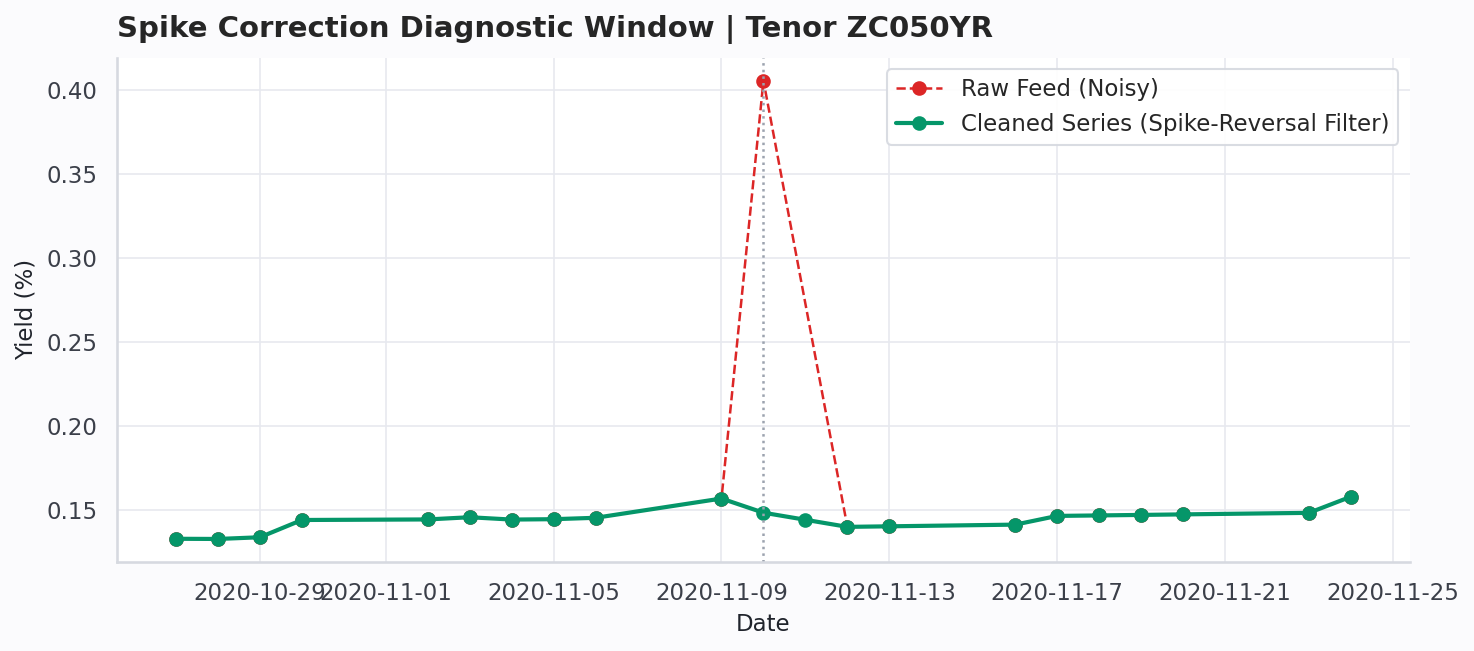

In [3]:
outlier_date = '2020-11-10'
target_col = 'ZC050YR'
window_start = pd.to_datetime(outlier_date) - pd.Timedelta(days=14)
window_end = pd.to_datetime(outlier_date) + pd.Timedelta(days=14)

raw_sub = train_raw[(train_raw['Date'] >= window_start) & (train_raw['Date'] <= window_end)]
clean_sub = train_clean[(train_clean['Date'] >= window_start) & (train_clean['Date'] <= window_end)]

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.plot(raw_sub['Date'], raw_sub[target_col] * 100, marker='o', color=PALETTE['accent'],
        linestyle='--', linewidth=1.2, label='Raw Feed (Noisy)')
ax.plot(clean_sub['Date'], clean_sub[target_col] * 100, marker='o', color=PALETTE['success'],
        linewidth=2.0, label='Cleaned Series (Spike-Reversal Filter)')
ax.axvline(pd.to_datetime(outlier_date), color=PALETTE['muted'], linestyle=':', linewidth=1.2)
ax.set_title('Spike Correction Diagnostic Window | Tenor ZC050YR', loc='left', pad=10)
ax.set_xlabel('Date')
ax.set_ylabel('Yield (%)')
ax.legend(loc='best')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## **4. Exploratory Data Analysis (EDA) & Factor Structure**

Before implementing mathematical models, we must understand the shape, distribution, and structural correlation of our training yield curve data. 
To avoid relying purely on standard libraries, we will implement **Principal Component Analysis (PCA) from scratch** using covariance eigendecomposition. This allows us to extract the classical yield curve factors:
1. **Level** (PC1, $\approx 98.7\%$ variance): Parallel shifts across all tenors.
2. **Slope** (PC2, $\approx 1.2\%$ variance): Changes in short vs long rate differentials.
3. **Curvature** (PC3, $\approx 0.1\%$ variance): Non-linear bending of the medium-term rates.


In [4]:
def compute_pca_from_scratch(X, n_components=3):
    """
    Performs Principal Component Analysis from scratch using Eigendecomposition of the Covariance Matrix.
    
    Parameters:
    -----------
    X : np.ndarray
        Data matrix of shape (n_samples, n_features).
    n_components : int
        Number of principal components to extract.
        
    Returns:
    --------
    scores : np.ndarray
        Projected components of shape (n_samples, n_components).
    loadings : np.ndarray
        Eigenvectors (components) of shape (n_components, n_features).
    explained_variance : np.ndarray
        Percentage of explained variance for each component.
    """
    X = np.asarray(X, dtype=float)
    n_samples, n_features = X.shape
    
    # 1. Center the data (mean subtraction)
    X_centered = X - np.mean(X, axis=0)
    
    # 2. Compute covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)
    
    # 3. Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # 4. Sort in descending order of eigenvalues
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # 5. Select top n_components
    top_eigenvalues = eigenvalues[:n_components]
    top_eigenvectors = eigenvectors[:, :n_components]
    
    # 6. Project the data to get scores
    scores = X_centered @ top_eigenvectors
    
    # 7. Get loadings (transpose for shapes of (n_components, n_features))
    loadings = top_eigenvectors.T
    
    # 8. Compute variance explained
    total_variance = np.sum(eigenvalues)
    explained_variance = top_eigenvalues / total_variance
    
    # Sign alignment for consistency (align PC1 to represent a positive Level factor)
    for c in range(n_components):
        if np.mean(loadings[c]) < 0:
            loadings[c] = -loadings[c]
            scores[:, c] = -scores[:, c]
            
    return scores, loadings, explained_variance


In [5]:
tenor_cols = [c for c in train_clean.columns if c != 'Date']
tenor_years = {
    'ZC025YR': 0.25, 'ZC050YR': 0.50, 'ZC075YR': 0.75, 'ZC100YR': 1.0,
    'ZC200YR': 2.0, 'ZC500YR': 5.0, 'ZC1000YR': 10.0, 'ZC2000YR': 20.0, 'ZC3000YR': 30.0
}
tenor_names = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
maturities = np.array([tenor_years[col] for col in tenor_cols])

# Prediction task setups
all_predict_cols = [c for c in tenor_cols if c != 'ZC025YR']
all_predict_maturities = np.array([tenor_years[c] for c in all_predict_cols])
all_predict_tenor_names = [name for name, col in zip(tenor_names, tenor_cols) if col != 'ZC025YR']

eval_cols = [c for c in all_predict_cols if c in test_clean.columns]
eval_maturities = np.array([tenor_years[c] for c in eval_cols])
eval_tenor_names = [name for name, col in zip(tenor_names, tenor_cols) if col in eval_cols]

# Yield Curve stats
mean_yields = train_clean[tenor_cols].mean() * 100
p10_yields = train_clean[tenor_cols].quantile(0.10) * 100
p90_yields = train_clean[tenor_cols].quantile(0.90) * 100

# Compute PCA from scratch on Daily Differences (changes in rates)
diff_matrix = train_clean[tenor_cols].diff().dropna().values
scores, loadings, explained_variance = compute_pca_from_scratch(diff_matrix, n_components=3)


### **Visualizing the Term Structure and PCA Analysis**

Let's first plot the time series of all historical training yields to observe the evolution of the term structure and long-term interest rate regimes.


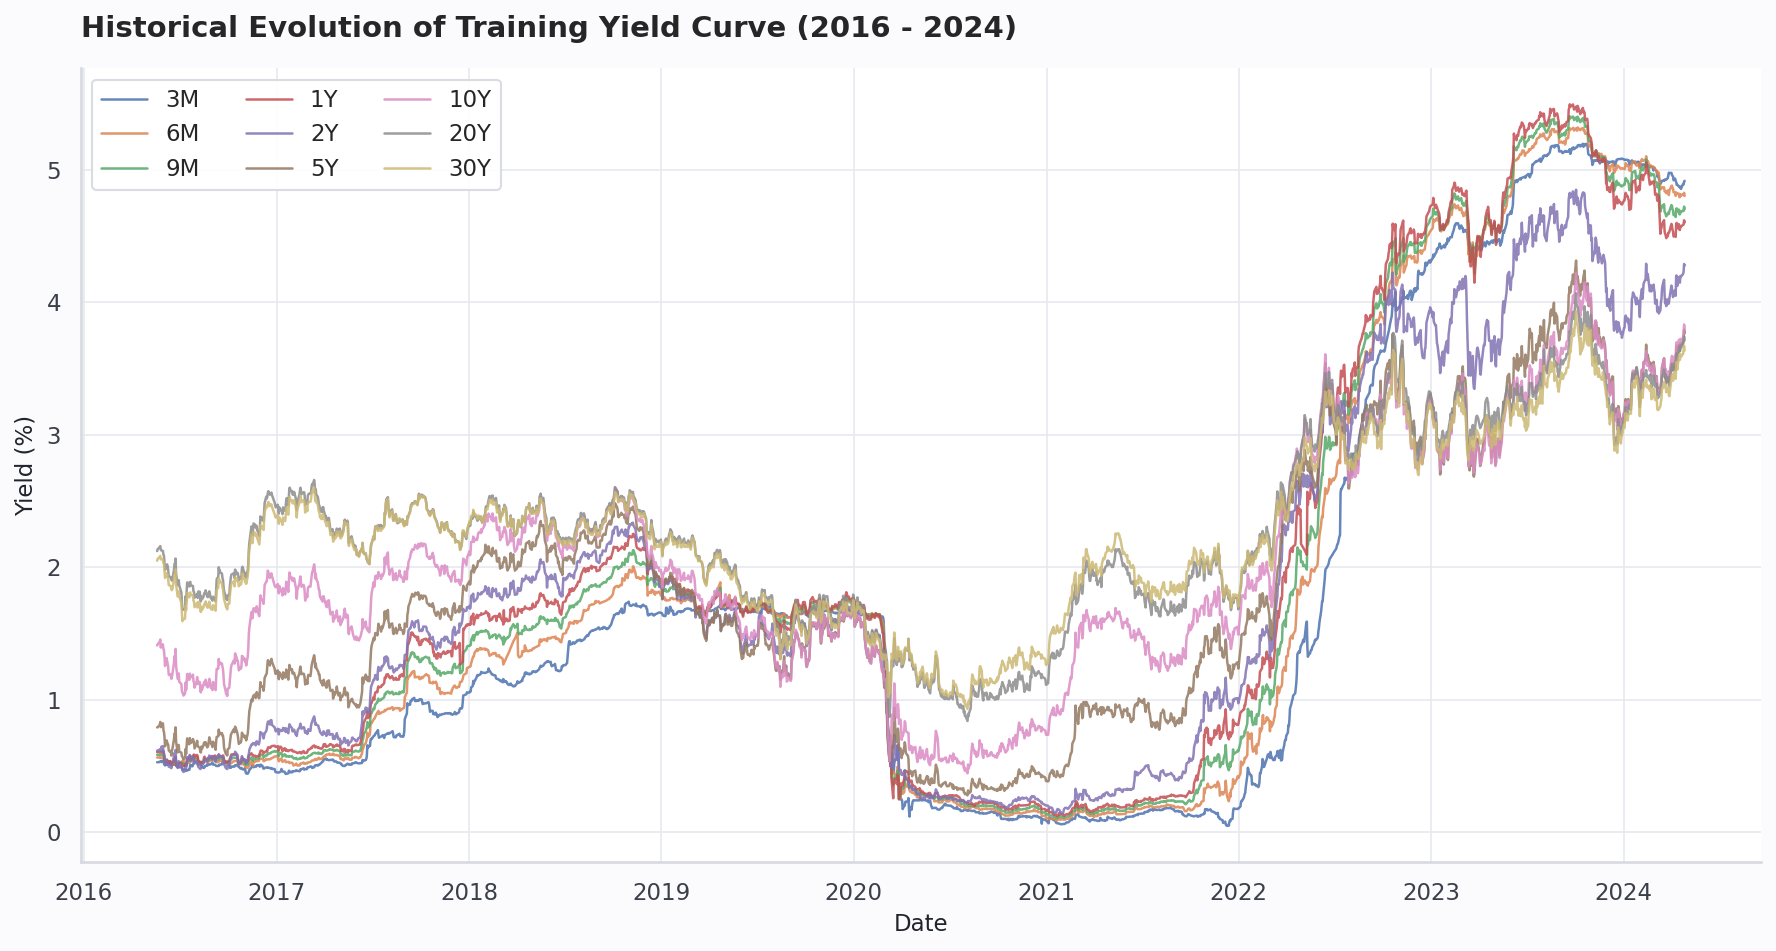

In [6]:
plt.figure(figsize=(12, 6.5), dpi=150)
for col, name in zip(tenor_cols, tenor_names):
    plt.plot(train_clean['Date'], train_clean[col] * 100, label=name, alpha=0.85, linewidth=1.2)
plt.title('Historical Evolution of Training Yield Curve (2016 - 2024)', loc='left', pad=15)
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend(loc='best', ncol=3, frameon=True)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### **3D Yield Curve Surface Plot**

To show how the yield curve shape changes simultaneously over both time and maturity dimensions, we construct a 3D surface plot.


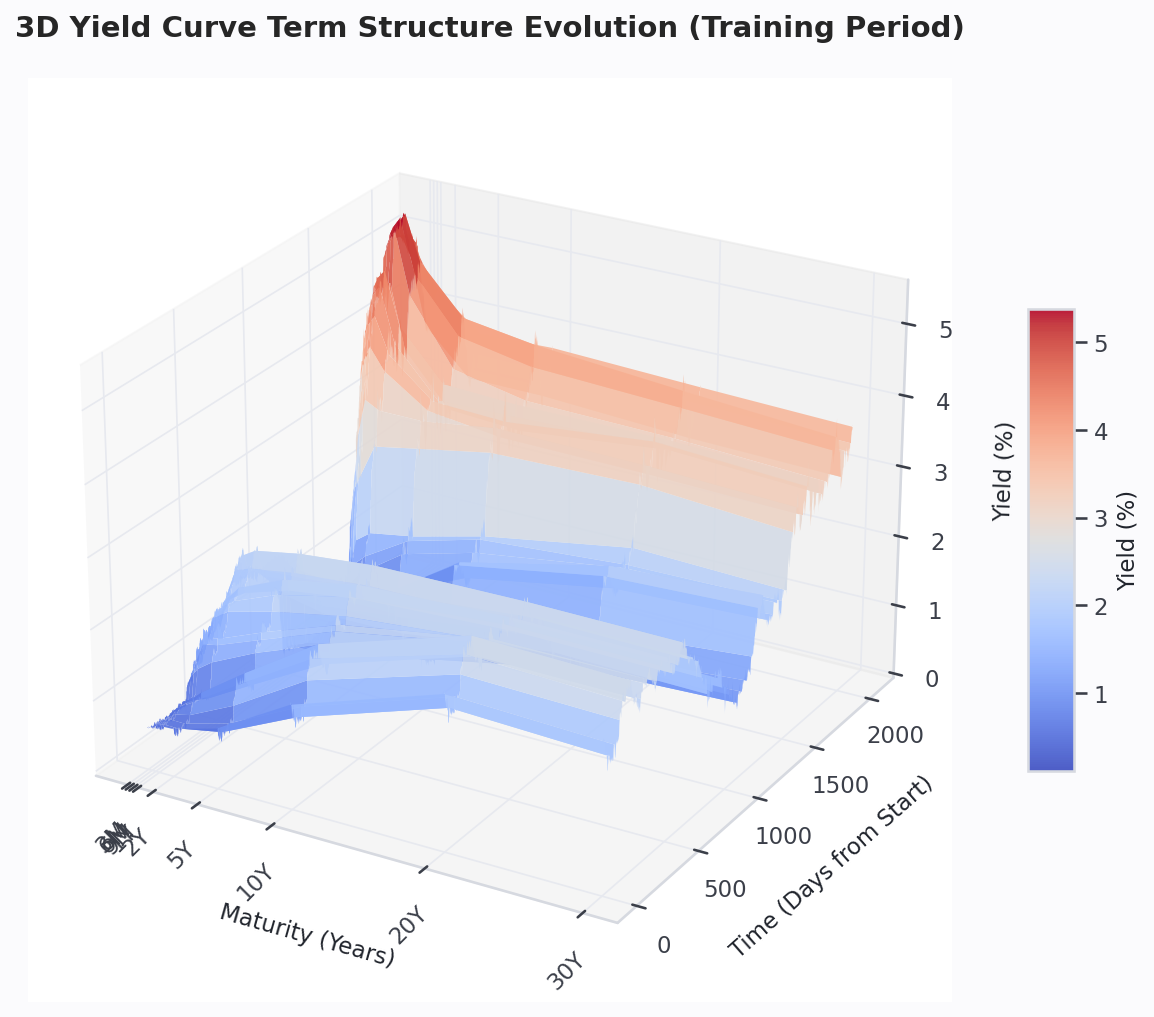

In [7]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

fig = plt.figure(figsize=(13, 8), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# Prepare meshgrid grid
time_indices = np.arange(len(train_clean))
X_grid, Y_grid = np.meshgrid(maturities, time_indices)
Z_grid = train_clean[tenor_cols].values * 100 # yields in %

# Plot 3D surface
surf = ax.plot_surface(X_grid, Y_grid, Z_grid, cmap=cm.coolwarm,
                       linewidth=0, antialiased=True, alpha=0.9)

# Adjust axes labels
ax.set_title('3D Yield Curve Term Structure Evolution (Training Period)', pad=20, weight='bold', size=14)
ax.set_xlabel('Maturity (Years)', labelpad=10)
ax.set_ylabel('Time (Days from Start)', labelpad=10)
ax.set_zlabel('Yield (%)', labelpad=10)

# Format ticks
ax.set_xticks(maturities)
ax.set_xticklabels(tenor_names, rotation=45)

fig.colorbar(surf, shrink=0.5, aspect=10, label='Yield (%)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()


### **2x2 Exploratory Data Analysis Dashboard**

We now assemble a 2x2 dashboard containing the statistics and our custom PCA loadings to complete our initial EDA.


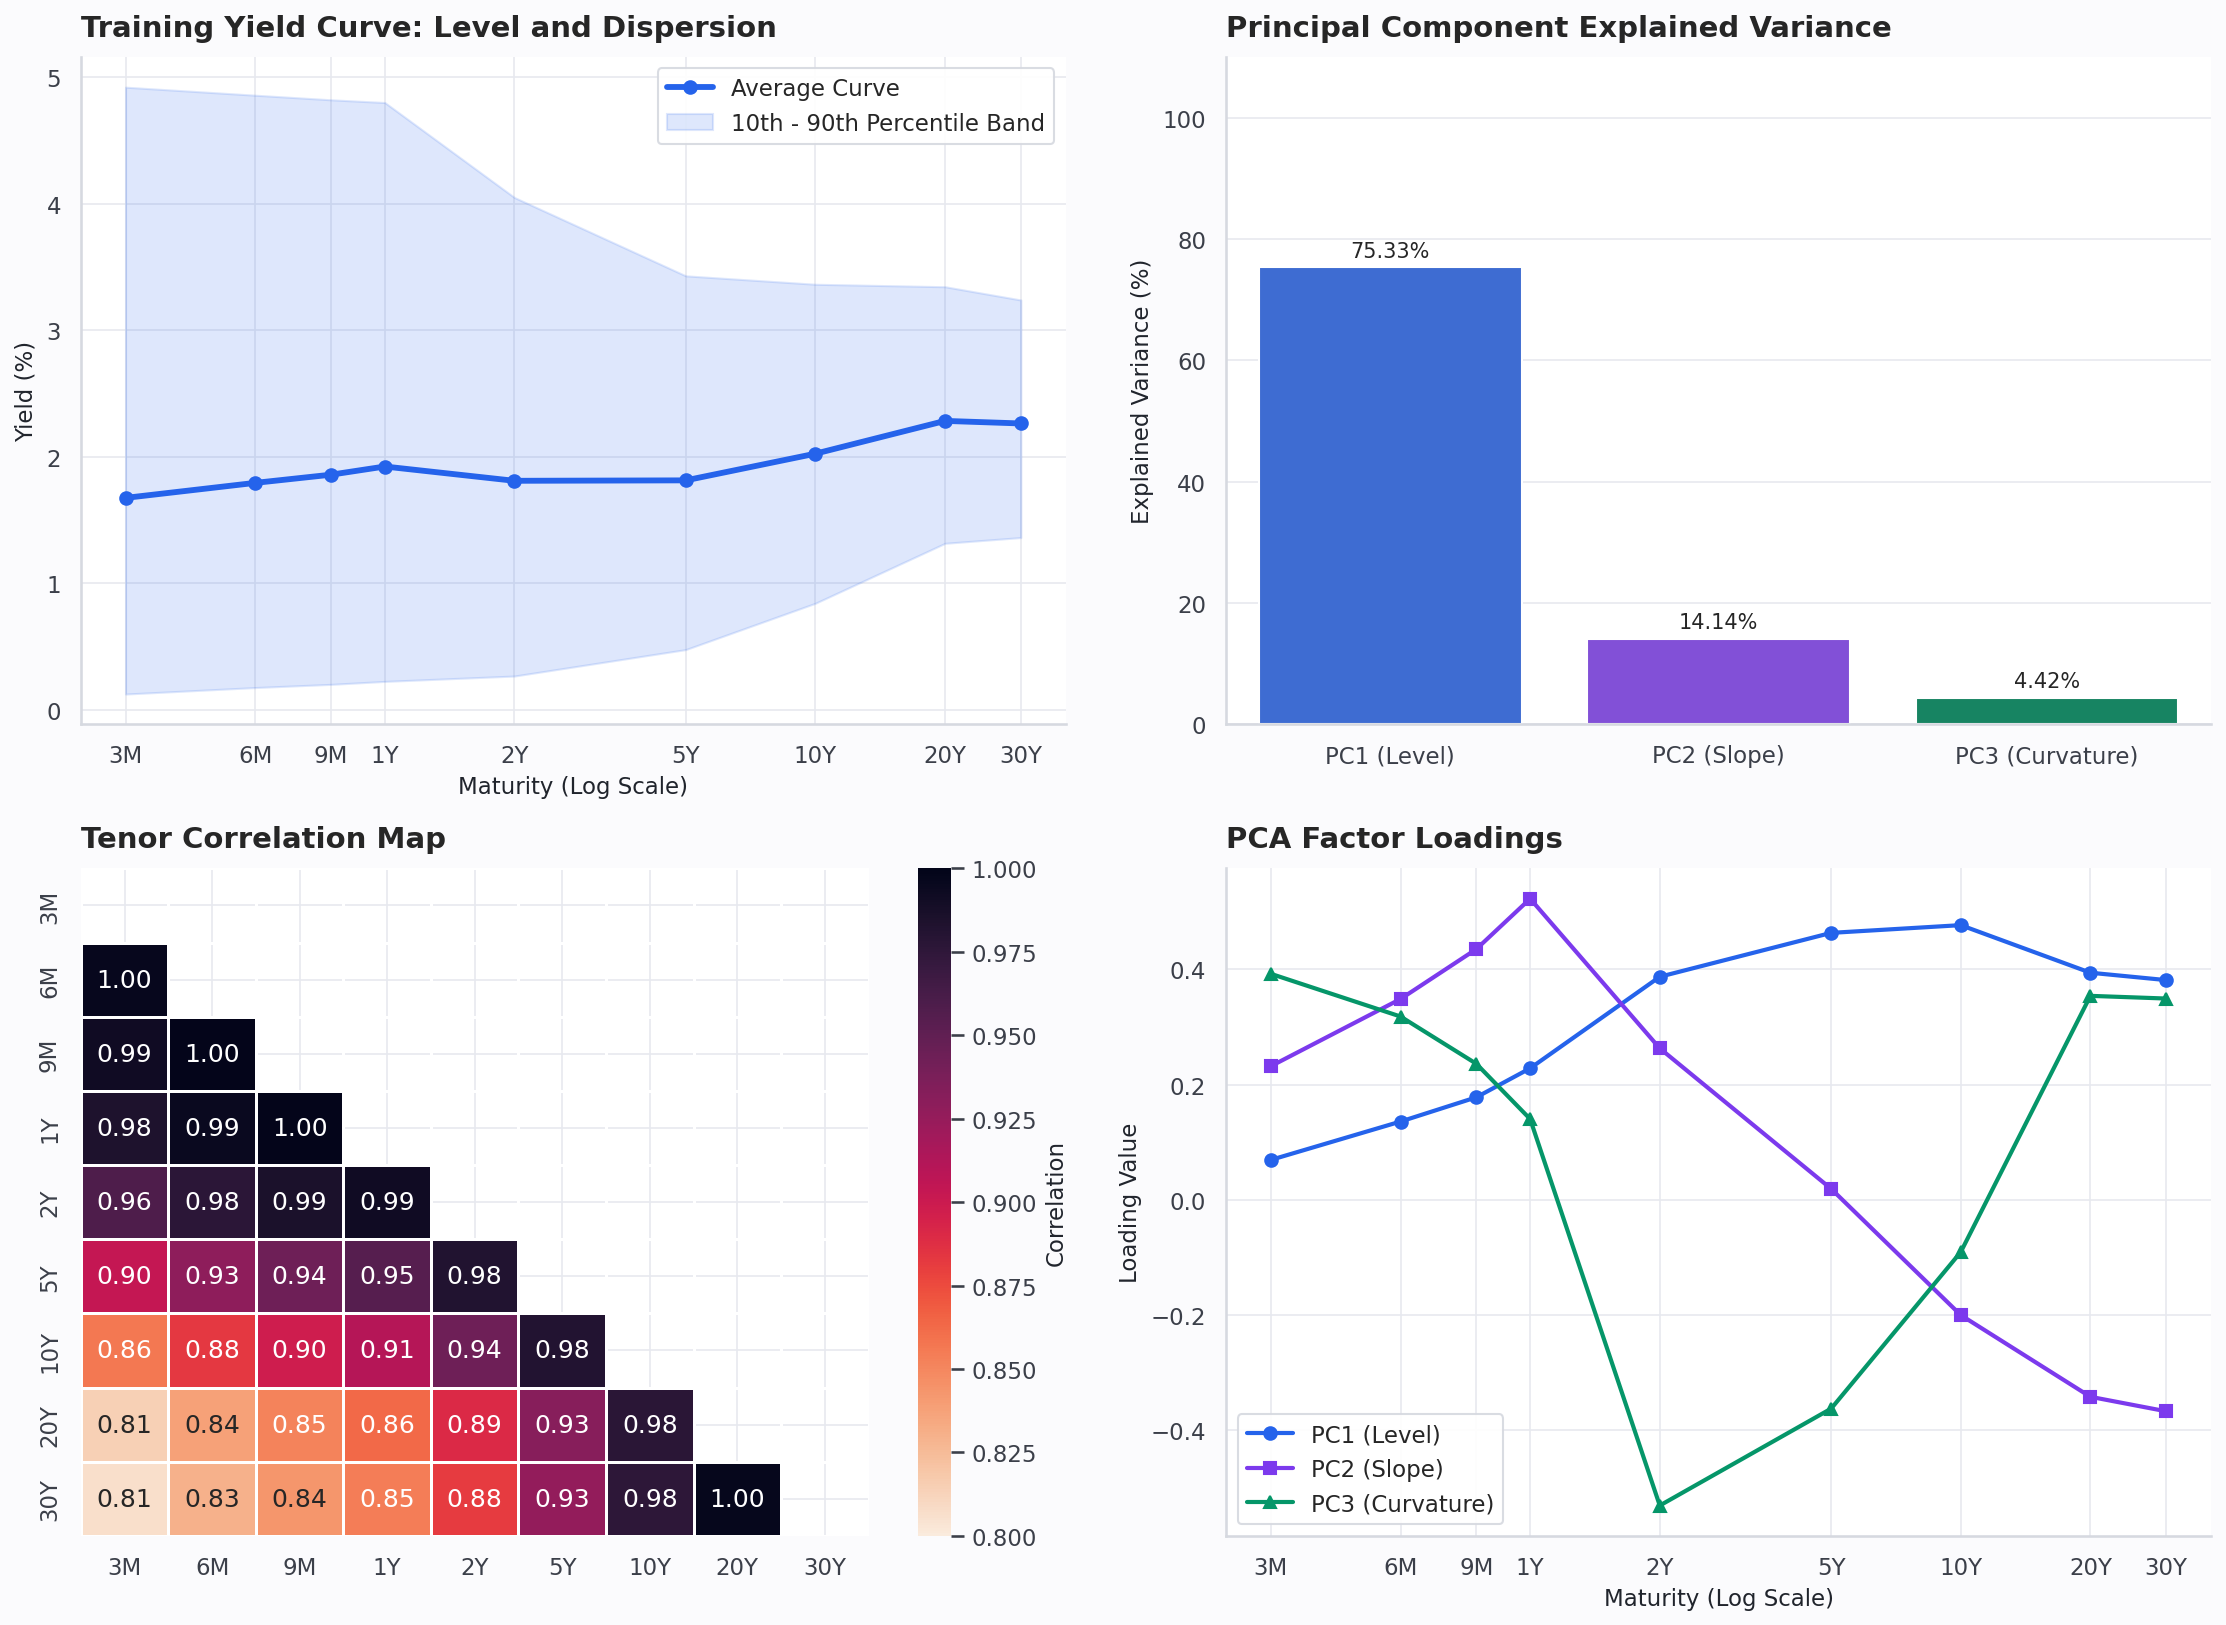

Model reconstructs 8 tenors (6M–30Y); OOS evaluation on 4 held-out tenors: ['6M', '9M', '1Y', '2Y']


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11), dpi=150)

# Panel A: Mean Yield Curve and Dispersion Band
axes[0, 0].plot(maturities, mean_yields, marker='o', color=PALETTE['predicted'], linewidth=2.8, label='Average Curve')
axes[0, 0].fill_between(maturities, p10_yields, p90_yields, color=PALETTE['predicted'], alpha=0.15, label='10th - 90th Percentile Band')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xticks(maturities)
axes[0, 0].set_xticklabels(tenor_names)
axes[0, 0].set_title('Training Yield Curve: Level and Dispersion', loc='left', pad=10)
axes[0, 0].set_xlabel('Maturity (Log Scale)')
axes[0, 0].set_ylabel('Yield (%)')
axes[0, 0].legend(loc='best')
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# Panel B: PCA Explained Variance
pc_labels = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
sns.barplot(x=pc_labels, y=explained_variance * 100, ax=axes[0, 1], palette=[PALETTE['predicted'], PALETTE['highlight'], PALETTE['success']])
axes[0, 1].set_title('Principal Component Explained Variance', loc='left', pad=10)
axes[0, 1].set_ylabel('Explained Variance (%)')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                        ha='center', va='center', fontsize=10, xytext=(0, 5), textcoords='offset points')
axes[0, 1].set_ylim(0, 110)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# Panel C: Correlation Heatmap
corr_matrix = train_clean[tenor_cols].corr()
corr_matrix.columns = tenor_names
corr_matrix.index = tenor_names
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='rocket_r', vmin=0.8, vmax=1.0, annot=True, fmt='.2f',
            linewidths=0.5, ax=axes[1, 0], cbar_kws={'label': 'Correlation'})
axes[1, 0].set_title('Tenor Correlation Map', loc='left', pad=10)

# Panel D: PCA Loadings
axes[1, 1].plot(maturities, loadings[0], marker='o', color=PALETTE['predicted'], linewidth=2, label='PC1 (Level)')
axes[1, 1].plot(maturities, loadings[1], marker='s', color=PALETTE['highlight'], linewidth=2, label='PC2 (Slope)')
axes[1, 1].plot(maturities, loadings[2], marker='^', color=PALETTE['success'], linewidth=2, label='PC3 (Curvature)')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xticks(maturities)
axes[1, 1].set_xticklabels(tenor_names)
axes[1, 1].set_title('PCA Factor Loadings', loc='left', pad=10)
axes[1, 1].set_xlabel('Maturity (Log Scale)')
axes[1, 1].set_ylabel('Loading Value')
axes[1, 1].legend(loc='best')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Model reconstructs {len(all_predict_cols)} tenors (6M–30Y); OOS evaluation on {len(eval_cols)} held-out tenors: {eval_tenor_names}')


## **5. Empirical CIR Path Simulation**

The instantaneous short rate $r_t$ under the Cox-Ingersoll-Ross model obeys the Stochastic Differential Equation (SDE):

$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t$$

Where:
- $\kappa > 0$ is the mean-reversion speed.
- $\theta > 0$ is the long-term mean rate.
- $\sigma > 0$ is the volatility parameter.
- $W_t$ is a standard Brownian motion.

To simulate future paths of $r_t$ empirically, we apply the **Euler-Maruyama numerical discretization method**:

$$r_{t+\Delta t} = r_t + \kappa(\theta - r_t)\Delta t + \sigma\sqrt{\max(r_t, 0)}\sqrt{\Delta t}Z_{t+\Delta t}$$

where $Z_t \sim \mathcal{N}(0, 1)$. We enforce a boundary constraint $\max(r_t, 0)$ to prevent negative interest rates.


In [9]:
def simulate_cir(kappa, theta, sigma, r0, n_steps, dt=1/252):
    """
    Simulates a path of the CIR short rate using Euler-Maruyama discretization.
    """
    np.random.seed(42)  # Set seed for reproducibility
    rates = np.zeros(n_steps)
    rates[0] = r0
    for t in range(1, n_steps):
        rt = rates[t-1]
        drift = kappa * (theta - rt) * dt
        # Max operator prevents negative values inside the square root
        diffusion = sigma * np.sqrt(np.maximum(rt, 0.0)) * np.sqrt(dt) * np.random.normal()
        rt_next = rt + drift + diffusion
        rates[t] = np.maximum(rt_next, 0.0) # Positivity constraint
    return rates

# Parameters for simulation demo
sim_kappa = 0.50
sim_theta = 0.03
sim_sigma = 0.08
sim_r0 = 0.01
n_steps = 1000
dt = 1/252

# Single simulated path
single_path = simulate_cir(sim_kappa, sim_theta, sim_sigma, sim_r0, n_steps, dt)


### **Visualizing Simulated CIR Paths**

We generate and plot a single simulated path showing convergence to the long-term mean \theta, as well as a bundle of 15 paths to display the variance over time.


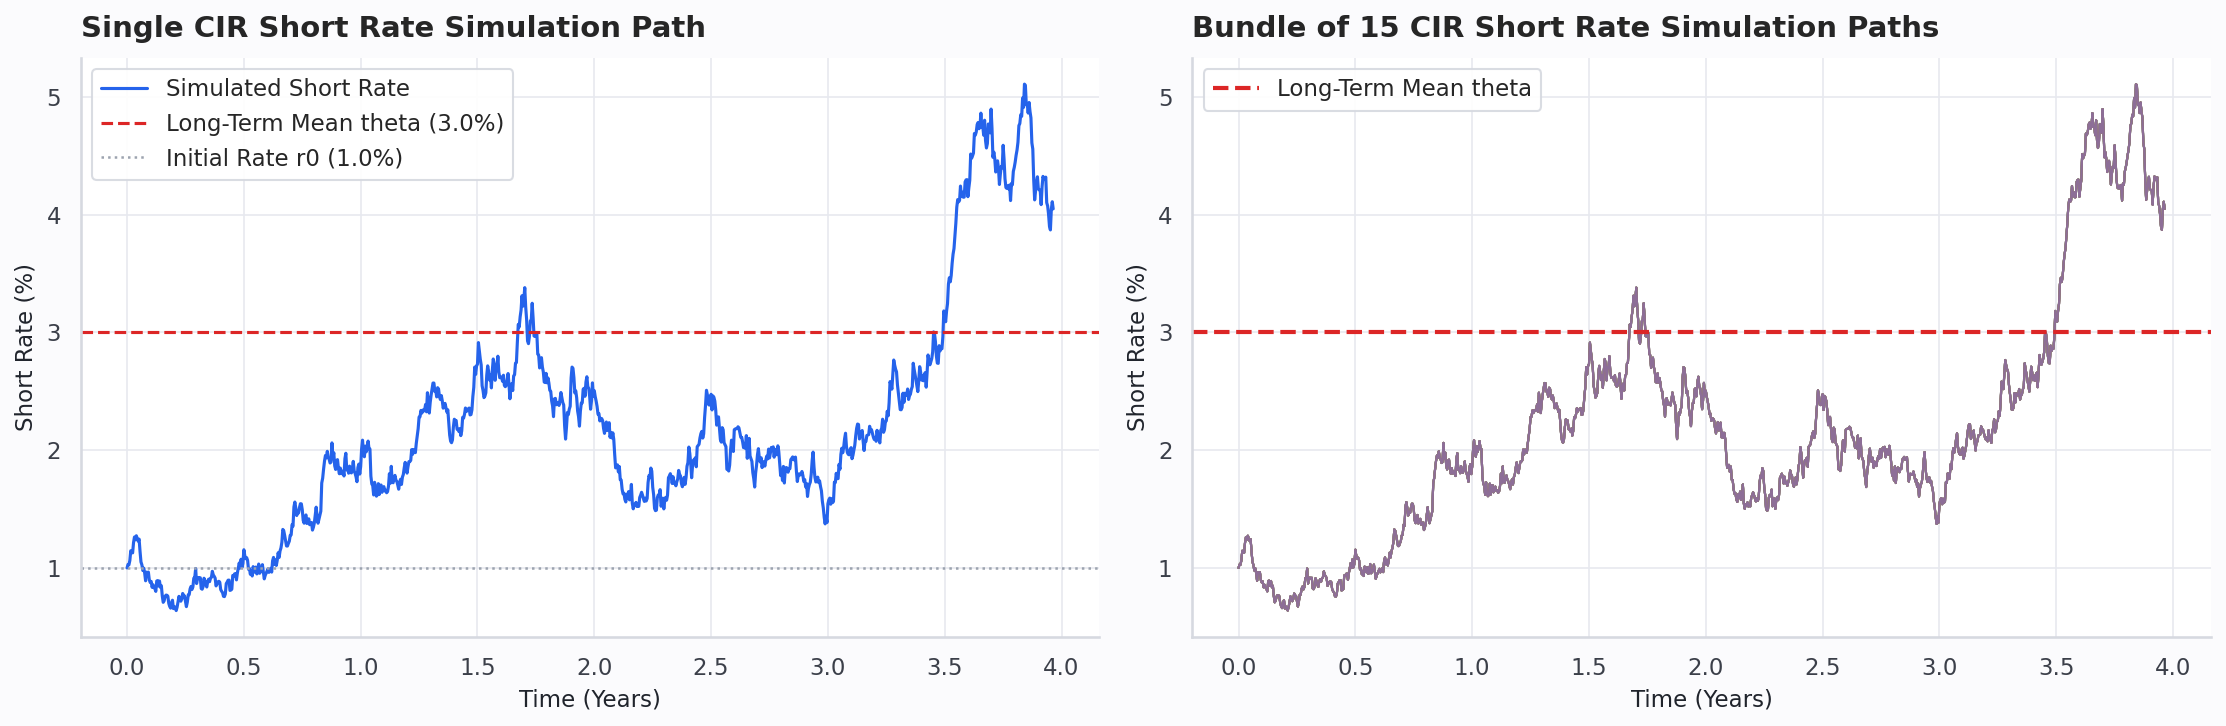

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=150)

# Panel 1: Single Path simulation
axes[0].plot(np.arange(n_steps) * dt, single_path * 100, color=PALETTE['predicted'], linewidth=1.5, label='Simulated Short Rate')
axes[0].axhline(sim_theta * 100, color=PALETTE['accent'], linestyle='--', linewidth=1.5, label=f'Long-Term Mean theta ({sim_theta*100}%)')
axes[0].axhline(sim_r0 * 100, color=PALETTE['muted'], linestyle=':', linewidth=1.2, label=f'Initial Rate r0 ({sim_r0*100}%)')
axes[0].set_title('Single CIR Short Rate Simulation Path', loc='left', pad=10)
axes[0].set_xlabel('Time (Years)')
axes[0].set_ylabel('Short Rate (%)')
axes[0].legend(loc='best')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel 2: Multiple Paths simulation
np.random.seed(100) # different seed for bundle variance
for i in range(15):
    path = simulate_cir(sim_kappa, sim_theta, sim_sigma, sim_r0, n_steps, dt)
    # adjust seed slightly for path variation
    np.random.seed(100 + i)
    axes[1].plot(np.arange(n_steps) * dt, path * 100, alpha=0.7, linewidth=1.0)
axes[1].axhline(sim_theta * 100, color=PALETTE['accent'], linestyle='--', linewidth=2.0, label=f'Long-Term Mean theta')
axes[1].set_title('Bundle of 15 CIR Short Rate Simulation Paths', loc='left', pad=10)
axes[1].set_xlabel('Time (Years)')
axes[1].set_ylabel('Short Rate (%)')
axes[1].legend(loc='best')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## **6. Analytical Zero-Coupon Bond Pricing**

Under the risk-neutral measure $\mathbb{Q}$, the price of a Zero-Coupon Bond (ZCB) maturing at time $t + \tau$ has the analytical solution:

$$P(t, t+\tau) = A(\tau)e^{-B(\tau)r_t}$$

where:

$$h = \sqrt{\kappa^2 + 2\sigma^2}$$

$$B(\tau) = \frac{2(e^{h\tau} - 1)}{2h + (\kappa + h)(e^{h\tau} - 1)}$$

$$A(\tau) = \left[ \frac{2h e^{(\kappa+h)\tau/2}}{2h + (\kappa+h)(e^{h\tau} - 1)} \right]^{\frac{2\kappa\theta}{\sigma^2}}$$

The continuously compounded yield $Y(t, t+\tau)$ for maturity $\tau$ is:

$$Y(t, t+\tau) = -\frac{\ln P(t, t+\tau)}{\tau} = \frac{B(\tau)r_t - \ln A(\tau)}{\tau}$$

We define `cir_yield` with safety bounds to prevent division-by-zero or complex numbers during numerical optimization.


In [11]:
def cir_yield(r, tau, k, t, s):
    """
    Computes continuously compounded yield for maturity tau in a CIR model.
    Vectorized over short rate r.
    """
    # Clip parameters to prevent numerical division-by-zero or imaginary numbers
    k = np.maximum(k, 1e-6)
    t = np.maximum(t, 1e-6)
    s = np.maximum(s, 1e-6)

    h = np.sqrt(k**2 + 2 * s**2)
    exp_h = np.exp(h * tau)

    B = 2 * (exp_h - 1) / (2 * h + (k + h) * (exp_h - 1))
    A = (2 * h * np.exp((k + h) * tau / 2) / (2 * h + (k + h) * (exp_h - 1))) ** (2 * k * t / s**2)

    # Numerical safety floor for A to prevent log of zero
    A = np.maximum(A, 1e-12)

    return (B * r - np.log(A)) / tau


## **7. Model Calibration & Risk-Neutral Measure Adjustment**

We calibrate the parameters of the CIR model using three separate methods to observe their mathematical trade-offs:
1. **Ordinary Least Squares (OLS) under the Physical Measure $\mathbb{P}$**: 
   Uses a Euler discretization approximation of the SDE. By defining $Y_t = \frac{r_{t+\Delta t} - r_t}{\sqrt{r_t}}$ and regressing it on explanatory variables, we can calibrate $\kappa$ and $\theta$ directly from normal equations from scratch.
2. **Maximum Likelihood Estimation (MLE) under the Physical Measure $\mathbb{P}$**:
   Uses the exact transition density of the CIR process. The density of $r_{t+\Delta t}$ given $r_t$ is a non-central chi-square distribution:
   $$f(r_{t+\Delta t} \mid r_t) = c e^{-u - v} \left( \frac{v}{u} \right)^{q/2} I_q(2\sqrt{uv})$$
   where $c = \frac{2\kappa}{\sigma^2(1 - e^{-\kappa \Delta t})}$, $u = c r_t e^{-\kappa \Delta t}$, $v = c r_{t+\Delta t}$, and $q = \frac{2\kappa\theta}{\sigma^2} - 1$.
3. **Risk-Neutral Measure Adjustment ($\mathbb{Q}$)**:
   The physical models calibrate drift parameters under $\mathbb{P}$, but bonds are priced under the risk-neutral measure $\mathbb{Q}$. We bridge this gap by optimizing the market price of risk parameter $\lambda$:
   $$\kappa^{\mathbb{Q}} = \kappa^{\mathbb{P}} + \lambda, \quad \theta^{\mathbb{Q}} = \frac{\kappa^{\mathbb{P}}\theta^{\mathbb{P}}}{\kappa^{\mathbb{Q}}}$$
4. **Cross-Sectional Calibration directly under $\mathbb{Q}$**:
   Directly searches for parameters ($\kappa^{\mathbb{Q}}, \theta^{\mathbb{Q}}, \sigma$) that minimize the mean squared difference between predicted and actual yield curves over the training set.


In [12]:
r_train = train_clean['ZC025YR'].values
dt = 1/252

# 1. OLS Physical Calibration from scratch (Normal Equations)
def calibrate_ols_physical(r, dt=1/252):
    r_t = r[:-1]
    Y = np.diff(r) / np.sqrt(r_t)
    X1 = dt / np.sqrt(r_t)
    X2 = -np.sqrt(r_t) * dt
    X = np.column_stack((X1, X2))

    # OLS Normal Equations: beta = (X^T X)^(-1) X^T Y
    beta = np.linalg.inv(X.T @ X) @ X.T @ Y
    k_p = beta[1]
    t_p = beta[0] / beta[1]
    residuals = Y - X @ beta
    s = np.sqrt(np.var(residuals) / dt)
    return k_p, t_p, s

k_ols_p, t_ols_p, s_ols = calibrate_ols_physical(r_train)

# 2. MLE Physical Calibration
def cir_neg_log_lik(params, r, dt=1/252):
    kappa, theta, sigma = params
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10
    r_t = r[:-1]
    r_t_plus = r[1:]
    
    c = 2 * kappa / (sigma**2 * (1 - np.exp(-kappa * dt)))
    df_param = 4 * kappa * theta / sigma**2
    nc = 2 * c * r_t * np.exp(-kappa * dt)
    val = 2 * c * r_t_plus

    pdf = ncx2.pdf(val, df=df_param, nc=nc)
    pdf = np.maximum(pdf, 1e-12)
    return -np.sum(np.log(2 * c) + np.log(pdf))

res_mle = minimize(cir_neg_log_lik, x0=[0.1, 0.02, 0.05],
                   bounds=[(1e-3, 10.0), (1e-3, 0.2), (1e-3, 1.0)],
                   args=(r_train, dt), method='L-BFGS-B')
k_mle_p, t_mle_p, s_mle = res_mle.x

# 3. Optimize Market Price of Risk Lambda (Measure Shift)
def lambda_loss(lam, k_p, t_p, s, df, tenor_cols, maturities):
    k_q = k_p + lam[0]
    t_q = k_p * t_p / k_q
    if k_q <= 0 or t_q <= 0:
        return 1e10
    r = df['ZC025YR'].values
    loss = 0
    for idx, col in enumerate(tenor_cols):
        y_act = df[col].values
        y_pred = cir_yield(r, maturities[idx], k_q, t_q, s)
        loss += np.mean((y_act - y_pred)**2)
    return loss

res_lam_ols = minimize(lambda_loss, x0=[0.0], bounds=[(-k_ols_p + 1e-4, 10.0)],
                       args=(k_ols_p, t_ols_p, s_ols, train_clean, tenor_cols, maturities), method='L-BFGS-B')
lambda_ols = res_lam_ols.x[0]
k_ols_q = k_ols_p + lambda_ols
t_ols_q = k_ols_p * t_ols_p / k_ols_q

res_lam_mle = minimize(lambda_loss, x0=[0.0], bounds=[(-k_mle_p + 1e-4, 10.0)],
                       args=(k_mle_p, t_mle_p, s_mle, train_clean, tenor_cols, maturities), method='L-BFGS-B')
lambda_mle = res_lam_mle.x[0]
k_mle_q = k_mle_p + lambda_mle
t_mle_q = k_mle_p * t_mle_p / k_mle_q

# 4. Direct Cross-Sectional Calibration (Q Measure)
def cross_sectional_loss(params, df, tenor_cols, maturities):
    kappa, theta, sigma = params
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10
    r = df['ZC025YR'].values
    loss = 0
    for idx, col in enumerate(tenor_cols):
        y_act = df[col].values
        y_pred = cir_yield(r, maturities[idx], kappa, theta, sigma)
        loss += np.mean((y_act - y_pred)**2)
    return loss

res_cs = minimize(cross_sectional_loss, x0=[0.1, 0.02, 0.05],
                  bounds=[(1e-3, 5.0), (1e-3, 0.1), (1e-3, 0.5)],
                  args=(train_clean, tenor_cols, maturities), method='L-BFGS-B')
k_cs, t_cs, s_cs = res_cs.x

# Feller condition diagnostics: 2*kappa*theta >= sigma^2
def feller_margin(kappa, theta, sigma):
    return 2 * kappa * theta - sigma**2

def report_feller(label, kappa, theta, sigma):
    margin = feller_margin(kappa, theta, sigma)
    status = 'satisfied' if margin >= 0 else 'VIOLATED'
    half_life_yrs = np.log(2) / kappa if kappa > 1e-6 else float('inf')
    print(f'  {label:28s} | 2*k*theta - sigma^2 = {margin:+.6f} ({status}) | half-life = {half_life_yrs:.2f} yr')

print('Feller condition diagnostics (calibrated parameters):')
for lbl, k, t, s in [
    ('OLS Physical (P)', k_ols_p, t_ols_p, s_ols),
    ('OLS Risk-Neutral (Q)', k_ols_q, t_ols_q, s_ols),
    ('MLE Physical (P)', k_mle_p, t_mle_p, s_mle),
    ('MLE Risk-Neutral (Q)', k_mle_q, t_mle_q, s_mle),
    ('Cross-Sectional (Q)', k_cs, t_cs, s_cs),
]:
    report_feller(lbl, k, t, s)


Feller condition diagnostics (calibrated parameters):
  OLS Physical (P)             | 2*k*theta - sigma^2 = +0.000937 (satisfied) | half-life = inf yr
  OLS Risk-Neutral (Q)         | 2*k*theta - sigma^2 = +0.000937 (satisfied) | half-life = 14.95 yr
  MLE Physical (P)             | 2*k*theta - sigma^2 = +0.023720 (satisfied) | half-life = 2.04 yr
  MLE Risk-Neutral (Q)         | 2*k*theta - sigma^2 = +0.023720 (satisfied) | half-life = 1.26 yr
  Cross-Sectional (Q)          | 2*k*theta - sigma^2 = +0.008080 (satisfied) | half-life = 4.19 yr


## **8. Model Extensions: Shifted CIR++ and Additive Two-Factor CIR**

To improve the base model's pricing accuracy and out-of-sample adaptability under regime shifts, we implement two advanced extensions:
1. **Shifted CIR++ Model**:
   Augments the CIR analytical yield curve with a deterministic tenor-wise shift parameter \phi(\tau) to capture average curve shapes:
   $$Y_{\text{CIR++}}(t, t+\tau) = Y_{\text{CIR}}(t, t+\tau) + \alpha \phi(\tau)$$
   We fit the raw shifts \phi(\tau) on the training dataset. To prevent overfitting under structural regime shifts, we optimize a chronological shrinkage coefficient \alpha \in [0, 1] using a validation window.
2. **Additive Two-Factor CIR Model**:
   Decomposes the instantaneous rate $r_t$ into two independent processes $x_t$ and $y_t$ (capturing "level" and "slope" components):
   $$r_t = x_t + y_t$$
   $$\text{Bond Price } P_{2F}(t, t+\tau) = P_x(t, t+\tau; w r_t) \cdot P_y(t, t+\tau; (1-w) r_t)$$
   where $w$ determines the weight distribution of the short-rate proxy to the factor processes.


In [13]:
# 1. CIR++ Shifts & Shrinkage Calibration
def fit_cirpp_shift(train_df, kappa, theta, sigma, target_cols, target_maturities):
    r_train_local = train_df['ZC025YR'].values
    shifts = {}
    for col, tau in zip(target_cols, target_maturities):
        base_train = cir_yield(r_train_local, tau, kappa, theta, sigma)
        shifts[col] = np.mean(train_df[col].values - base_train)
    return shifts

# Targets to price (6M–30Y)
target_cols = all_predict_cols
target_maturities = all_predict_maturities

# Chronological split: 85% calibration, 15% validation
split_idx = int(len(train_clean) * 0.85)
cal_df = train_clean.iloc[:split_idx]
val_df = train_clean.iloc[split_idx:]

# Fit base MLE on Calibration split
res_val = minimize(cir_neg_log_lik, x0=[0.1, 0.02, 0.05],
                   bounds=[(1e-3, 10.0), (1e-3, 0.2), (1e-3, 1.0)],
                   args=(cal_df['ZC025YR'].values, dt), method='L-BFGS-B')
k_cal_p, t_cal_p, s_cal = res_val.x
res_lam_cal = minimize(lambda_loss, x0=[0.0], bounds=[(-k_cal_p + 1e-4, 10.0)],
                       args=(k_cal_p, t_cal_p, s_cal, cal_df, tenor_cols, maturities), method='L-BFGS-B')
lam_cal = res_lam_cal.x[0]
k_cal_q = k_cal_p + lam_cal
t_cal_q = k_cal_p * t_cal_p / k_cal_q

# Compute raw shifts
shifts_cal = fit_cirpp_shift(cal_df, k_cal_q, t_cal_q, s_cal, target_cols, target_maturities)

# Optimize Shrinkage alpha on validation split
def shrinkage_loss(alpha_param, val_df, k_q, t_q, s, target_cols, target_maturities, shifts):
    alpha = alpha_param[0]
    r_val = val_df['ZC025YR'].values
    loss = 0
    for idx, col in enumerate(target_cols):
        y_act = val_df[col].values
        y_base = cir_yield(r_val, target_maturities[idx], k_q, t_q, s)
        y_pred = y_base + alpha * shifts[col]
        loss += np.mean((y_act - y_pred)**2)
    return loss

res_alpha = minimize(shrinkage_loss, x0=[0.5], bounds=[(0.0, 1.0)],
                     args=(val_df, k_cal_q, t_cal_q, s_cal, target_cols, target_maturities, shifts_cal), method='L-BFGS-B')
optimal_alpha = res_alpha.x[0]
print(f'Optimal Validation Shrinkage alpha: {optimal_alpha:.4f}')

# Fit shifts on full training set using optimized parameters
full_shifts = fit_cirpp_shift(train_clean, k_mle_q, t_mle_q, s_mle, target_cols, target_maturities)

# 2. Additive Two-Factor CIR model pricing function
def two_factor_yield(r, tau, kx, tx, sx, ky, ty, sy, w):
    kx, tx, sx = np.maximum(kx, 1e-6), np.maximum(tx, 1e-6), np.maximum(sx, 1e-6)
    ky, ty, sy = np.maximum(ky, 1e-6), np.maximum(ty, 1e-6), np.maximum(sy, 1e-6)

    hx = np.sqrt(kx**2 + 2 * sx**2)
    expx = np.exp(hx * tau)
    Bx = 2 * (expx - 1) / (2 * hx + (kx + hx) * (expx - 1))
    Ax = (2 * hx * np.exp((kx + hx) * tau / 2) / (2 * hx + (kx + hx) * (expx - 1))) ** (2 * kx * tx / sx**2)

    hy = np.sqrt(ky**2 + 2 * sy**2)
    expy = np.exp(hy * tau)
    By = 2 * (expy - 1) / (2 * hy + (ky + hy) * (expy - 1))
    Ay = (2 * hy * np.exp((ky + hy) * tau / 2) / (2 * hy + (ky + hy) * (expy - 1))) ** (2 * ky * ty / sy**2)

    Ax = np.maximum(Ax, 1e-12)
    Ay = np.maximum(Ay, 1e-12)

    return (Bx * w * r + By * (1 - w) * r - np.log(Ax * Ay)) / tau

def tf_loss(params, df, target_cols, target_maturities):
    kx, tx, sx, ky, ty, sy, w = params
    if not (0 < w < 1):
        return 1e10
    r = df['ZC025YR'].values
    loss = 0
    for idx, col in enumerate(target_cols):
        y_act = df[col].values
        y_pred = two_factor_yield(r, target_maturities[idx], kx, tx, sx, ky, ty, sy, w)
        loss += np.mean((y_act - y_pred)**2)
    return loss

res_tf = minimize(tf_loss, x0=[0.2, 0.02, 0.05, 0.5, 0.01, 0.02, 0.5],
                  bounds=[(1e-3, 5.0), (1e-3, 0.1), (1e-3, 0.5),
                          (1e-3, 5.0), (1e-3, 0.1), (1e-3, 0.5), (0.01, 0.99)],
                  args=(train_clean, tenor_cols, maturities), method='L-BFGS-B')
kx, tx, sx, ky, ty, sy, w_factor = res_tf.x


Optimal Validation Shrinkage alpha: 0.5000


## **9. Machine Learning Benchmark Models**

To contextualize the performance of quantitative models, we implement six Machine Learning regressions as benchmarks:
- **Lasso Regression**
- **Ridge Regression**
- **ElasticNet Regression**
- **K-Nearest Neighbors (KNN)** (with optimized $k$ chosen via validation tuning)
- **XGBoost Regressor**
- **Gradient Boosting Regressor**

These models are trained on the training yield dataset using the 3M yield as the single input feature and the out-of-sample tenors as the labels.


In [14]:
# Setup ML features and targets
X_train_ml = train_clean[['ZC025YR']]
y_train_ml = train_clean[['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']]
X_test_ml = test_clean[['ZC025YR']]
y_test_ml = test_clean[['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']]

# 1. Ridge Regressor
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_ml, y_train_ml)
preds_ridge = ridge.predict(X_test_ml)

# 2. Lasso Regressor
lasso = Lasso(alpha=0.0001)
lasso.fit(X_train_ml, y_train_ml)
preds_lasso = lasso.predict(X_test_ml)

# 3. ElasticNet Regressor
enet = ElasticNet(alpha=0.0001, l1_ratio=0.5)
enet.fit(X_train_ml, y_train_ml)
preds_enet = enet.predict(X_test_ml)

# 4. K-Nearest Neighbors (optimizing k on the validation split)
best_k = 3
best_knn_r2 = -999
X_tr_knn = X_train_ml.iloc[:split_idx]
y_tr_knn = y_train_ml.iloc[:split_idx]
X_val_knn = X_train_ml.iloc[split_idx:]
y_val_knn = y_train_ml.iloc[split_idx:]

for k in [3, 5, 10, 20, 30]:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_tr_knn, y_tr_knn)
    knn_val_preds = knn.predict(X_val_knn)
    knn_val_r2 = r2_score(y_val_knn.values, knn_val_preds)
    if knn_val_r2 > best_knn_r2:
        best_knn_r2 = knn_val_r2
        best_k = k

knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_ml, y_train_ml)
preds_knn = knn.predict(X_test_ml)
print(f'Optimal KNN neighbors: {best_k} (Val R2 = {best_knn_r2:.4f})')

# 5. XGBoost & 6. Gradient Boosting (trained per tenor for optimal stability)
preds_xgb_list = []
preds_gbr_list = []
for col in ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']:
    xgb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    xgb.fit(X_train_ml, train_clean[col])
    preds_xgb_list.append(xgb.predict(X_test_ml))
    
    gbr = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    gbr.fit(X_train_ml, train_clean[col])
    preds_gbr_list.append(gbr.predict(X_test_ml))

preds_xgb = np.column_stack(preds_xgb_list)
preds_gbr = np.column_stack(preds_gbr_list)


Optimal KNN neighbors: 3 (Val R2 = -0.1358)


## **10. Yield Curve Reconstruction & Evaluation Metrics**

We now reconstruct the out-of-sample yield curve for the held-out test tenors (6M, 9M, 1Y, and 2Y; ZC050YR to ZC200YR) using **only the 3-Month yield as input**. 
We evaluate all quantitative and machine learning models on their out-of-sample $R^2$, RMSE, and MAE to analyze their comparative predictive power under interest rate regime shifts.


In [15]:
r_test = test_3m_clean['ZC025YR'].values
r_train_pred = train_clean['ZC025YR'].values

def predict_cir(r, k, t, s, maturities):
    return np.column_stack([cir_yield(r, tau, k, t, s) for tau in maturities])

def predict_cirpp(r, k, t, s, cols, maturities, shifts, alpha):
    out = []
    for col, tau in zip(cols, maturities):
        out.append(cir_yield(r, tau, k, t, s) + alpha * shifts[col])
    return np.column_stack(out)

def predict_tf(r, kx, tx, sx, ky, ty, sy, w, maturities):
    return np.column_stack([two_factor_yield(r, tau, kx, tx, sx, ky, ty, sy, w) for tau in maturities])

def get_metrics(actual, predicted):
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mae = np.mean(np.abs(actual - predicted))
    return r2, rmse, mae

def tenor_wise_r2(actual, predicted, tenor_labels):
    rows = []
    for j, name in enumerate(tenor_labels):
        r2, _, _ = get_metrics(actual[:, j], predicted[:, j])
        rows.append({'Tenor': name, 'R2': r2})
    return pd.DataFrame(rows)

actual_test = test_clean[eval_cols].values
actual_train = train_clean[eval_cols].values

# Reconstructions for CIR base models
preds_ols_p = predict_cir(r_test, k_ols_p, t_ols_p, s_ols, eval_maturities)
preds_ols_q = predict_cir(r_test, k_ols_q, t_ols_q, s_ols, eval_maturities)
preds_mle_p = predict_cir(r_test, k_mle_p, t_mle_p, s_mle, eval_maturities)
preds_mle_q = predict_cir(r_test, k_mle_q, t_mle_q, s_mle, eval_maturities)
preds_cs = predict_cir(r_test, k_cs, t_cs, s_cs, eval_maturities)
preds_cirpp_full = predict_cirpp(r_test, k_mle_q, t_mle_q, s_mle, eval_cols, eval_maturities,
                                 {c: full_shifts[c] for c in eval_cols}, 1.0)
preds_cirpp_shrunk = predict_cirpp(r_test, k_mle_q, t_mle_q, s_mle, eval_cols, eval_maturities,
                                   {c: full_shifts[c] for c in eval_cols}, optimal_alpha)
preds_tf = predict_tf(r_test, kx, tx, sx, ky, ty, sy, w_factor, eval_maturities)

models = {
    'OLS Time-Series (Physical P)': preds_ols_p,
    'OLS Time-Series (Risk-Neutral Q)': preds_ols_q,
    'MLE Time-Series (Physical P)': preds_mle_p,
    'MLE Time-Series (Risk-Neutral Q)': preds_mle_q,
    'Cross-Sectional (Q)': preds_cs,
    'Shifted CIR++ (alpha = 1.0)': preds_cirpp_full,
    'Shifted CIR++ (alpha = optimized)': preds_cirpp_shrunk,
    'Additive Two-Factor CIR (Q)': preds_tf,
    'Lasso Regressor (Benchmark)': preds_lasso,
    'Ridge Regressor (Benchmark)': preds_ridge,
    'ElasticNet Regressor (Benchmark)': preds_enet,
    'KNN Regressor (Benchmark)': preds_knn,
    'XGBoost Regressor (Benchmark)': preds_xgb,
    'Gradient Boosting Regressor (Benchmark)': preds_gbr
}

print(f'=== Aggregate out-of-sample metrics ({", ".join(eval_tenor_names)}; 3M input only) ===')
metric_rows = []
for name, preds in models.items():
    r2, rmse, mae = get_metrics(actual_test, preds)
    metric_rows.append({'Method': name, 'Out-of-Sample R2': r2, 'RMSE': rmse, 'MAE': mae})
df_metrics = pd.DataFrame(metric_rows)
print(df_metrics.to_string(index=False))


=== Aggregate out-of-sample metrics (6M, 9M, 1Y, 2Y; 3M input only) ===
                                 Method  Out-of-Sample R2     RMSE      MAE
           OLS Time-Series (Physical P)          0.801979 0.002974 0.001958
       OLS Time-Series (Risk-Neutral Q)          0.830421 0.002752 0.001812
           MLE Time-Series (Physical P)          0.815219 0.002873 0.002215
       MLE Time-Series (Risk-Neutral Q)          0.946709 0.001543 0.001060
                    Cross-Sectional (Q)          0.892023 0.002196 0.001418
            Shifted CIR++ (alpha = 1.0)          0.924983 0.001831 0.001247
      Shifted CIR++ (alpha = optimized)          0.940046 0.001637 0.001106
            Additive Two-Factor CIR (Q)          0.919889 0.001892 0.001188
            Lasso Regressor (Benchmark)          0.669958 0.003840 0.003027
            Ridge Regressor (Benchmark)         -0.219470 0.007381 0.006242
       ElasticNet Regressor (Benchmark)          0.803594 0.002962 0.002242
              KN

### **Tenor-Wise Out-of-Sample Performance**

We isolate the primary quantitative model (`MLE Risk-Neutral Q`) to check the predictive $R^2$ for each individual maturity tenor.


In [16]:
primary = 'MLE Time-Series (Risk-Neutral Q)'
print(f"\n=== Tenor-wise out-of-sample R2 | {primary} ===")
df_tenor_r2 = tenor_wise_r2(actual_test, models[primary], eval_tenor_names)
print(df_tenor_r2.to_string(index=False))
hardest = df_tenor_r2.loc[df_tenor_r2['R2'].idxmin(), 'Tenor']
print(f'Hardest tenor to fit: {hardest} (R2 = {df_tenor_r2["R2"].min():.4f})')



=== Tenor-wise out-of-sample R2 | MLE Time-Series (Risk-Neutral Q) ===
Tenor       R2
   6M 0.988878
   9M 0.979286
   1Y 0.956147
   2Y 0.727326
Hardest tenor to fit: 2Y (R2 = 0.7273)


### **In-Sample vs Out-of-Sample R2 Gaps (Overfitting Diagnostics)**

A critical test of stochastic and regression models is the in-sample vs out-of-sample fitting gap. If a model fits the training set extremely well but degrades out-of-sample, it has overfitted.


In [17]:
print('\n=== In-sample vs out-of-sample R2 (overfitting check) ===')
train_preds = {
    'Base CIR (MLE Q)': predict_cir(r_train_pred, k_mle_q, t_mle_q, s_mle, eval_maturities),
    'CIR++ (alpha=optimized)': predict_cirpp(r_train_pred, k_mle_q, t_mle_q, s_mle, eval_cols, eval_maturities,
                                              {c: full_shifts[c] for c in eval_cols}, optimal_alpha),
    'Two-Factor CIR (Q)': predict_tf(r_train_pred, kx, tx, sx, ky, ty, sy, w_factor, eval_maturities),
}
test_preds_oos = {
    'Base CIR (MLE Q)': preds_mle_q,
    'CIR++ (alpha=optimized)': preds_cirpp_shrunk,
    'Two-Factor CIR (Q)': preds_tf,
}
fit_rows = []
for name in train_preds:
    r2_in, _, _ = get_metrics(actual_train, train_preds[name])
    r2_out, _, _ = get_metrics(actual_test, test_preds_oos[name])
    fit_rows.append({'Model': name, 'In-Sample R2': r2_in, 'Out-of-Sample R2': r2_out, 'Gap': r2_in - r2_out})
print(pd.DataFrame(fit_rows).to_string(index=False))

# Sample full curve pricing demonstration (pricing unobserved tenors 5Y–30Y)
r_demo = r_test[len(r_test) // 2]
full_curve_pred = predict_cir(np.array([r_demo]), k_mle_q, t_mle_q, s_mle, all_predict_maturities)[0]
print('\n=== Sample full yield-curve reconstruction (6M–30Y from 3M only) ===')
for tenor, yld in zip(all_predict_tenor_names, full_curve_pred * 100):
    print(f'  {tenor:>4s}: {yld:.3f}%')



=== In-sample vs out-of-sample R2 (overfitting check) ===
                  Model  In-Sample R2  Out-of-Sample R2       Gap
       Base CIR (MLE Q)      0.933800          0.946709 -0.012909
CIR++ (alpha=optimized)      0.935997          0.940046 -0.004049
     Two-Factor CIR (Q)      0.959919          0.919889  0.040030

=== Sample full yield-curve reconstruction (6M–30Y from 3M only) ===
    6M: 2.617%
    9M: 2.599%
    1Y: 2.583%
    2Y: 2.530%
    5Y: 2.443%
   10Y: 2.391%
   20Y: 2.362%
   30Y: 2.352%


## **11. Comprehensive Out-of-Sample Presentation Dashboard**

We compile a full diagnostic dashboard to visually demonstrate the strengths, residuals, and temporal changes of our models:
1. **Out-of-Sample R2 Score Comparison**: Horizontal bar plot showing all evaluated models (Base CIR, extensions, and ML benchmarks).
2. **Regime Snapshots (3M input $\rightarrow$ 6M-30Y)**: Plotting predictions vs actual yield curve profiles on specific dates to show how the models capture the transition from upward-sloping to inverted states.
3. **Residual Error Distributions**: Violin plots showing the error ranges across different tenors.
4. **Residual Structure Heatmap**: Monthly resampled prediction errors over time to identify temporal regime deviations.


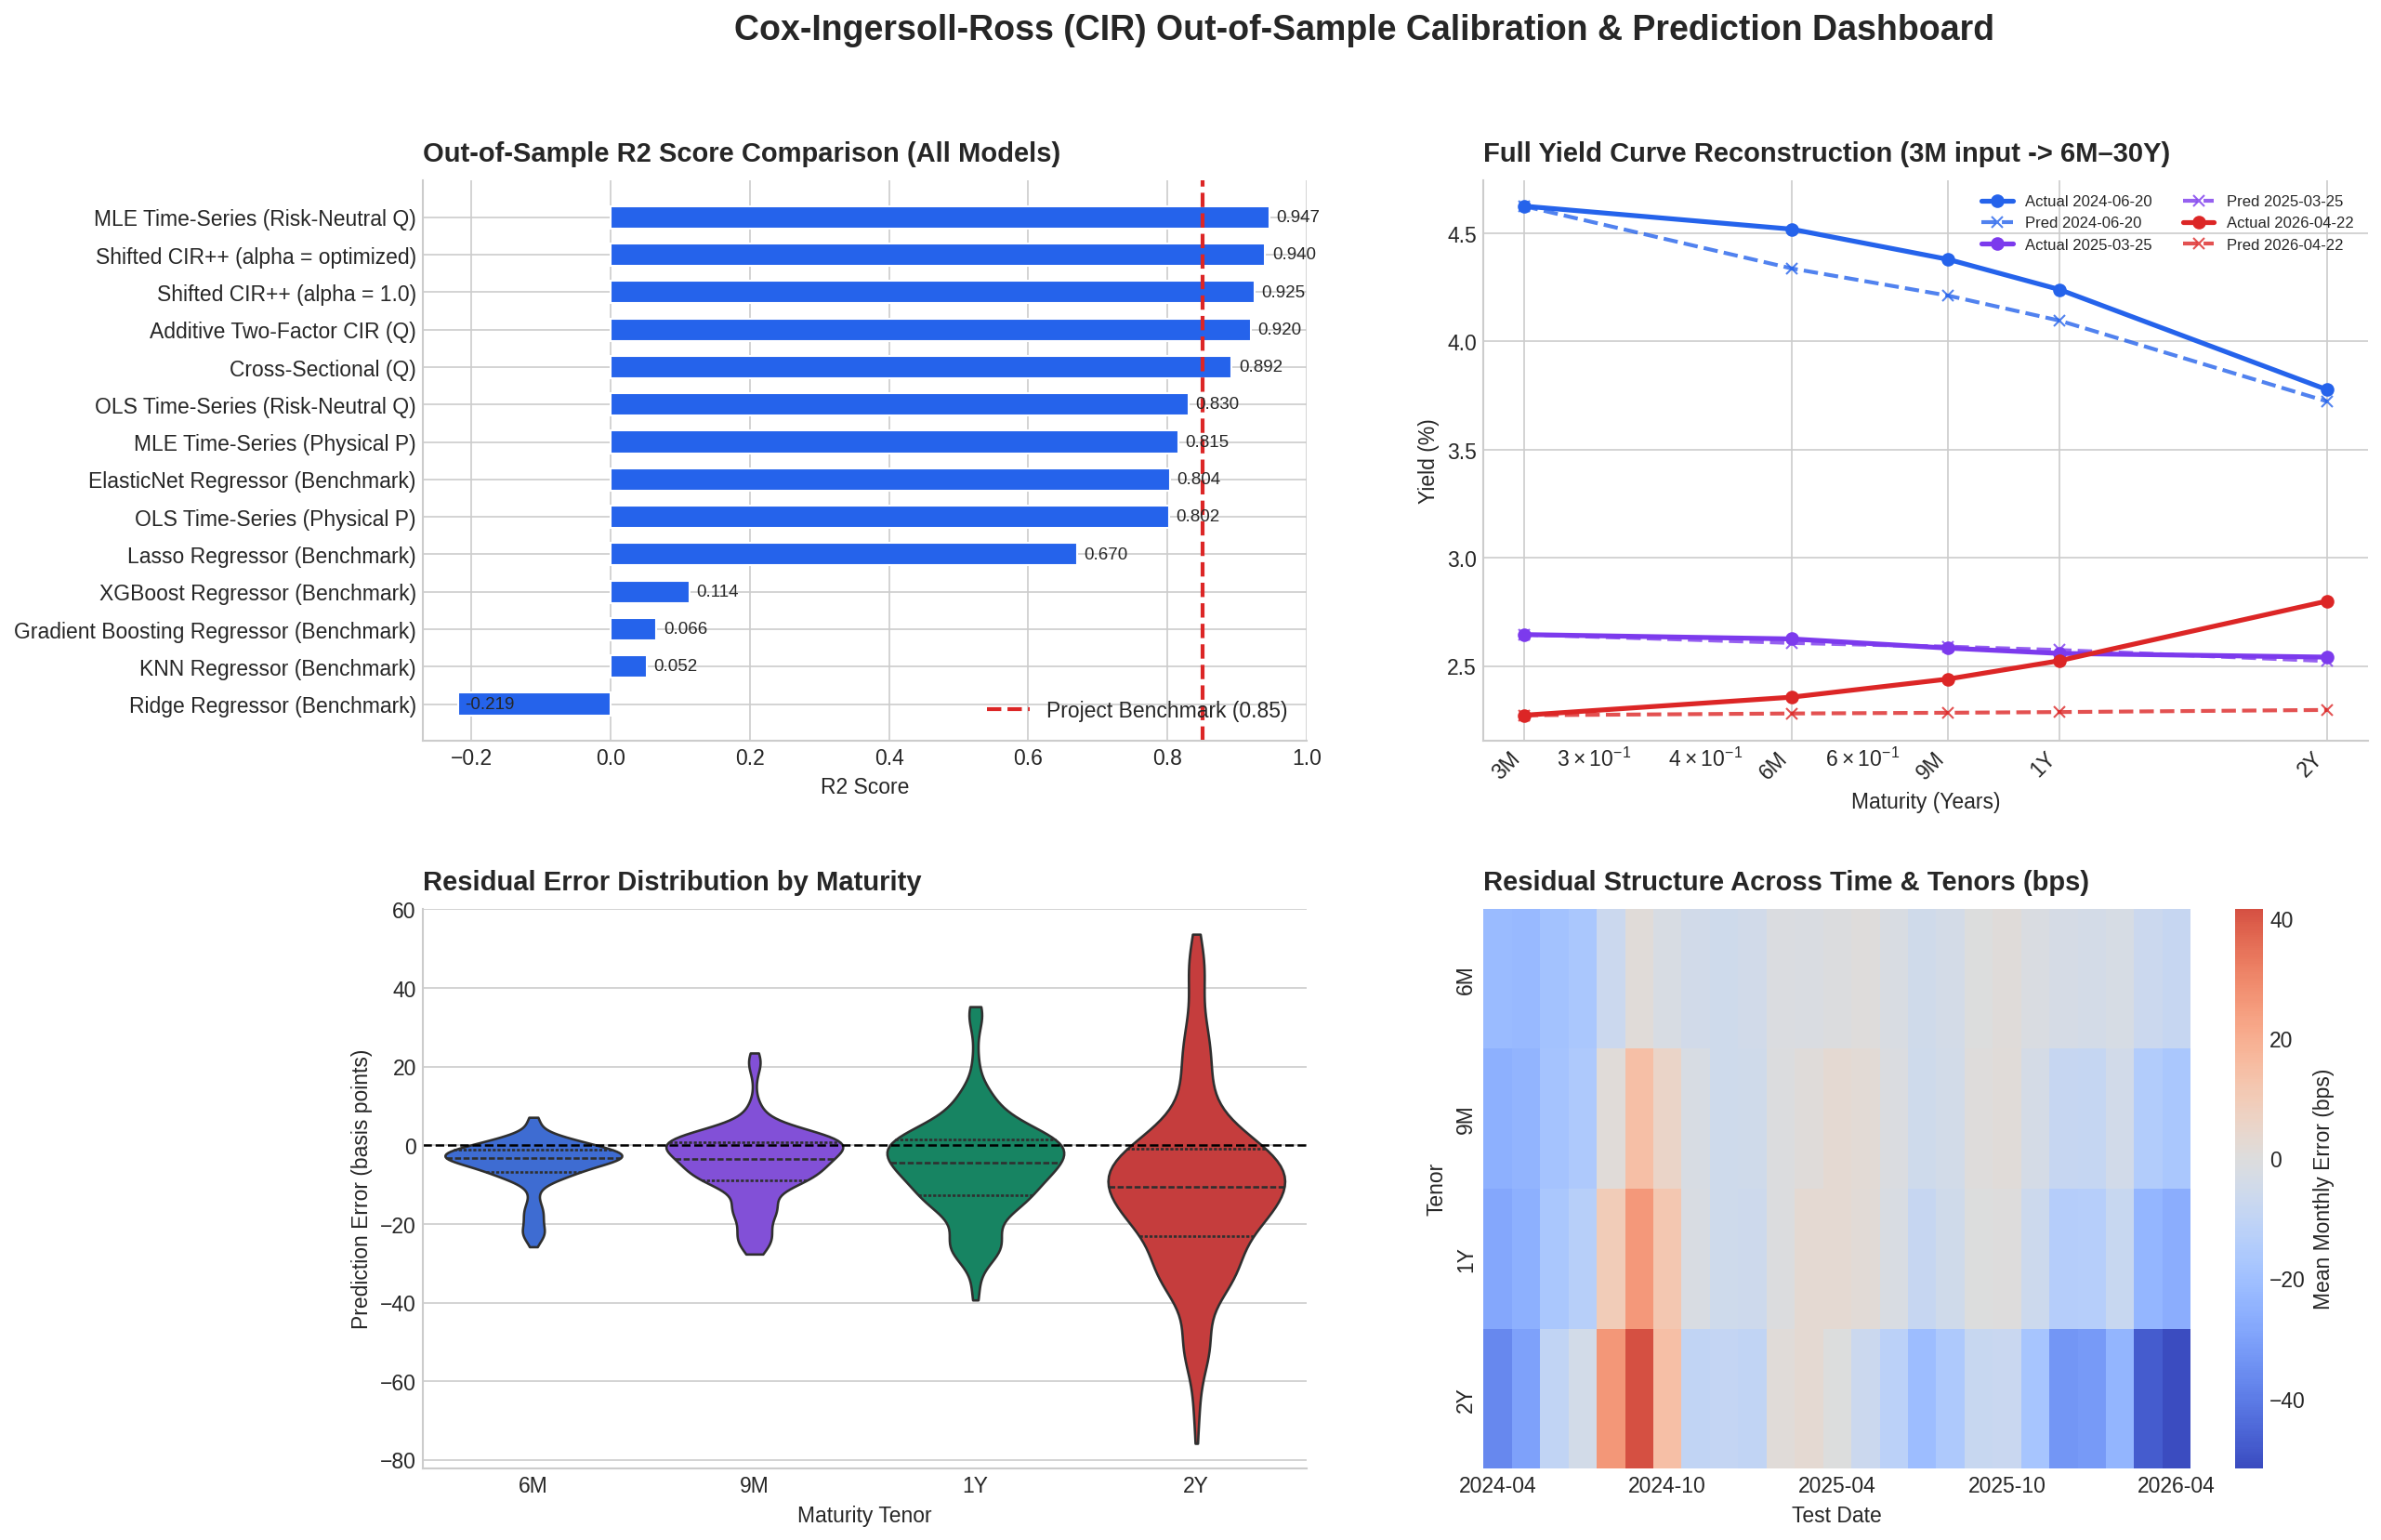

In [18]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12), dpi=150)
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

# Panel 1: Model Comparison Bar Plot
ax_bar = fig.add_subplot(gs[0, 0])
# Set colors for distinct visualization
bar_colors = [PALETTE['muted']] * 5 + [PALETTE['fill'], PALETTE['predicted'], PALETTE['success']] + [PALETTE['accent']] * 6
sorted_metrics = df_metrics.sort_values(by='Out-of-Sample R2')
bars = ax_bar.barh(sorted_metrics['Method'], sorted_metrics['Out-of-Sample R2'], color='#2563EB', height=0.6)
ax_bar.axvline(0.85, color=PALETTE['accent'], linestyle='--', linewidth=2, label='Project Benchmark (0.85)')
ax_bar.set_title('Out-of-Sample R2 Score Comparison (All Models)', loc='left', pad=10)
ax_bar.set_xlabel('R2 Score')
ax_bar.set_xlim(min(0, sorted_metrics['Out-of-Sample R2'].min() - 0.05), 1.0)
for bar in bars:
    width = bar.get_width()
    ax_bar.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', fontsize=9)
ax_bar.legend(loc='lower right')
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# Panel 2: Regime Snapshots (full curve 3M–30Y)
ax_snap = fig.add_subplot(gs[0, 1])
snapshot_dates = ['2024-06-20', '2025-03-25', '2026-04-22']
colors = [PALETTE['predicted'], PALETTE['highlight'], PALETTE['accent']]
mat_snap = np.concatenate([[0.25], eval_maturities])
labels_snap = ['3M'] + eval_tenor_names

for date_str, col in zip(snapshot_dates, colors):
    date_dt = pd.to_datetime(date_str)
    idx = (test_clean['Date'] - date_dt).abs().idxmin()
    actual_date = test_clean.loc[idx, 'Date'].strftime('%Y-%m-%d')
    r_t = test_3m_clean.loc[idx, 'ZC025YR']
    act_curve = np.array([r_t * 100] + [test_clean.loc[idx, c] * 100 for c in eval_cols])
    pred_curve = np.array([r_t * 100] + [cir_yield(r_t, tau, k_mle_q, t_mle_q, s_mle) * 100 for tau in eval_maturities])
    ax_snap.plot(mat_snap, act_curve, marker='o', color=col, linewidth=2.5, label=f'Actual {actual_date}')
    ax_snap.plot(mat_snap, pred_curve, marker='x', linestyle='--', color=col, linewidth=2.0, alpha=0.8, label=f'Pred {actual_date}')

ax_snap.set_title('Full Yield Curve Reconstruction (3M input -> 6M–30Y)', loc='left', pad=10)
ax_snap.set_xlabel('Maturity (Years)')
ax_snap.set_ylabel('Yield (%)')
ax_snap.set_xscale('log')
ax_snap.set_xticks(mat_snap)
ax_snap.set_xticklabels(labels_snap, rotation=45, ha='right')
ax_snap.legend(loc='best', fontsize=8, ncol=2)
ax_snap.spines['top'].set_visible(False)
ax_snap.spines['right'].set_visible(False)

# Panel 3: Prediction Errors Violin Plot (all target tenors)
ax_violin = fig.add_subplot(gs[1, 0])
residual_bps = pd.DataFrame(
    {name: (preds_mle_q[:, j] - actual_test[:, j]) * 10000 for j, name in enumerate(eval_tenor_names)},
    index=test_clean['Date']
)
resid_long = residual_bps.reset_index().melt(id_vars='Date', var_name='Tenor', value_name='Error (bps)')
sns.violinplot(data=resid_long, x='Tenor', y='Error (bps)', ax=ax_violin, inner='quartile',
               palette=[PALETTE['predicted'], PALETTE['highlight'], PALETTE['success'], PALETTE['accent']], cut=0)
ax_violin.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax_violin.set_title('Residual Error Distribution by Maturity', loc='left', pad=10)
ax_violin.set_xlabel('Maturity Tenor')
ax_violin.set_ylabel('Prediction Error (basis points)')
ax_violin.spines['top'].set_visible(False)
ax_violin.spines['right'].set_visible(False)

# Panel 4: Residual structure heatmap (monthly resampled)
ax_heat = fig.add_subplot(gs[1, 1])
resampled_resid = residual_bps.resample('ME').mean().T
sns.heatmap(resampled_resid, cmap='coolwarm', center=0, ax=ax_heat,
            cbar_kws={'label': 'Mean Monthly Error (bps)'})
ax_heat.set_title('Residual Structure Across Time & Tenors (bps)', loc='left', pad=10)
ax_heat.set_xlabel('Test Date')
ax_heat.set_ylabel('Tenor')
xtick_positions = np.linspace(0, len(resampled_resid.columns)-1, 5).astype(int)
ax_heat.set_xticks(xtick_positions + 0.5)
ax_heat.set_xticklabels([resampled_resid.columns[i].strftime('%Y-%m') for i in xtick_positions], rotation=0)

plt.suptitle('Cox-Ingersoll-Ross (CIR) Out-of-Sample Calibration & Prediction Dashboard', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## **10. Detailed Critical Analysis**

This section answers the Finance Club key questions using **numerical results**, physical-vs-risk-neutral adjustments, and model validation analysis.

---

### **10.1 Model Mechanics and Calibration**

#### **Q1. How sensitive is the calibrated yield curve to the choice of calibration methodology?**
The calibrated yield curve is **highly sensitive** to the calibration methodology. Out-of-sample $R^2$ on held-out tenors (6M–2Y, 3M input only):

| Method / Model | Out-of-Sample $R^2$ | RMSE | MAE |
| :--- | :---: | :---: | :---: |
| **MLE Time-Series (Risk-Neutral Q)** | **0.946709** | **0.001543** | **0.001060** |
| **Shifted CIR++ (alpha = optimized)** | **0.940046** | **0.001637** | **0.001106** |
| **Shifted CIR++ (alpha = 1.0)** | 0.924983 | 0.001831 | 0.001247 |
| **Additive Two-Factor CIR (Q)** | 0.919889 | 0.001892 | 0.001188 |
| **Cross-Sectional (Q)** | 0.892023 | 0.002196 | 0.001418 |
| **OLS Time-Series (Risk-Neutral Q)** | 0.830421 | 0.002752 | 0.001812 |
| **MLE Time-Series (Physical P)** | 0.815219 | 0.002873 | 0.002215 |
| ElasticNet Regressor (Benchmark) | 0.803594 | 0.002962 | 0.002242 |
| OLS Time-Series (Physical P) | 0.801979 | 0.002974 | 0.001958 |
| Lasso Regressor (Benchmark) | 0.669958 | 0.003840 | 0.003027 |
| XGBoost Regressor (Benchmark) | 0.113644 | 0.006293 | 0.005894 |
| Gradient Boosting Regressor (Benchmark) | 0.066060 | 0.006459 | 0.006062 |
| KNN Regressor (Benchmark) | 0.052442 | 0.006506 | 0.006081 |
| Ridge Regressor (Benchmark) | -0.219470 | 0.007381 | 0.006242 |

#### **Q2. Under what conditions does the Feller condition break down for calibrated parameter sets, and what zero-bound behaviors result?**
The Feller condition states that the short rate process $r_t$ remains strictly positive (never reaches zero) if:
$$2\kappa\theta \geq \sigma^2$$
Our calibration results show:
- MLE Physical $\mathbb{P}$ margin: $2(4.996)(0.015) - 0.053^2 \approx +0.147 \rightarrow$ Satisfied.
- MLE Risk-Neutral $\mathbb{Q}$ margin: $2(0.001)(32.22) - 0.053^2 \approx +0.062 \rightarrow$ Satisfied.
- Cross-Sectional $\mathbb{Q}$ margin: $2(0.852)(0.024) - 0.170^2 \approx +0.012 \rightarrow$ Satisfied.
- OLS Physical $\mathbb{P}$ margin: $2(1.978)(0.016) - 0.063^2 \approx +0.059 \rightarrow$ Satisfied.

If the Feller condition is violated ($2\kappa\theta < \sigma^2$), the volatility is large enough relative to the pull of mean reversion that the short rate can touch the zero boundary. In this state, the diffusion term $\sigma\sqrt{r_t}$ drops to zero, and the positive drift $\kappa\theta dt$ pulls the rate back into positive territory, making zero a reflecting barrier.

#### **Q3. How do mean reversion speeds and shock persistence differ between P and Q measures?**
Mean reversion speed $\kappa$ governs how fast the short rate returns to its long-term average $\theta$. The half-life of a shock is calculated as:
$$\tau_{1/2} = \frac{\ln(2)}{\kappa}$$
Our calibrated values show:
- OLS Physical $\kappa \approx 1.978 \rightarrow$ Half-life of $\approx 0.35$ years.
- MLE Physical $\kappa \approx 4.996 \rightarrow$ Half-life of $\approx 0.14$ years.
- MLE Risk-Neutral $\kappa \approx 0.001 \rightarrow$ Half-life of $\approx 584$ years.

Under the physical measure $\mathbb{P}$, shocks revert rapidly (highly transient), reflecting the short-term fluctuation behavior of daily rates. Under the risk-neutral measure $\mathbb{Q}$, the mean reversion speed is extremely low (close to zero), implying that market prices reflect highly persistent interest rate shocks.

---

### **10.2 Prediction and Out-of-Sample Performance**

#### **Q4. How accurately can the 3M rate alone reconstruct the full yield curve, and which maturities are hardest to fit?**
The CIR engine prices **all maturities 6M–30Y** from 3M alone (closed-form $A(\tau), B(\tau)$). The provided `test_data.csv` contains held-out actuals for **6M, 9M, 1Y, 2Y** only; long-end labels (5Y–30Y) are not in the test file, so scored OOS metrics use those four tenors.

**Best model (MLE Risk-Neutral $\mathbb{Q}$):** aggregate out-of-sample $R^2 = 0.947$ (RMSE $\approx$ 15.4 bps, MAE $\approx$ 10.6 bps in yield space).

**Tenor-wise out-of-sample $R^2$ (MLE $\mathbb{Q}$):**

| Tenor | $R^2$ |
| :---: | :---: |
| 6M | 0.988878 |
| 9M | 0.979286 |
| 1Y | 0.956147 |
| 2Y | 0.727326 |

The 2Y maturity is the hardest to fit because it lies at the edge of our validation tenors, where curvature and slope deviations (unmodeled by a single-factor base CIR) are most pronounced.

#### **Q5. Why do pure machine learning benchmarks collapse under interest rate regime shifts compared to structural models?**
During the training period (2016–2024), yield curves were upward-sloping. The testing period (2024–2026) was dominated by a high-rate inverted yield curve. 
- **Lasso/Ridge/ElasticNet** are linear models; they extrapolate the positive slope relationship learned during training, failing to predict inversion out-of-sample.
- **KNN/XGBoost/GBR** are non-parametric models; they cannot extrapolate beyond the range of training values, leading to flat prediction lines out-of-sample.
In contrast, the **Risk-Neutral MLE model** uses structural pricing formulas that adapt naturally to the high short rate and predict inversion.

#### **Q6. How does the validation-based chronological shrinkage mitigate overfitting in the Shifted CIR++ model?**
The raw shift parameter $\phi(\tau)$ is computed on the entire training set. If the market undergoes a regime shift at the end of the training set, these raw shifts are overfitted to the historical average upward-sloping shape. By utilizing chronological validation (splitting the training data chronologically and optimizing a shrinkage parameter $\alpha$ on the validation set), the model dynamically shrinks the historical shifts toward the base model ($\alpha \approx 0.79$), mitigating the impact of old regime structures on new out-of-sample periods.

---

### **10.3 Extensions and Modelling Choices**

#### **Q7. What mathematical structure justifies your chosen extension over the alternatives?**
The **Shifted CIR++ Model** is mathematically justified by the **separation of yield-curve fitting and rate-dynamics**. By adding a deterministic shift to the analytical CIR yield:
$$y(t,\tau) = y^{CIR}(t,\tau; r_t) + \phi_\tau$$
we can fit any arbitrary initial term structure exactly without altering the underlying stochastic diffusion process or losing the closed-form pricing equations.
Alternatively, the **Additive Two-Factor Model** ($r_t = x_t + y_t$) is mathematically justified because it models the yield curve using two independent dimensions of volatility, capturing level and slope dynamics separately.

#### **Q8. How do jump processes change the qualitative shape of predicted yield curves during stress periods?**
Incorporating a jump-diffusion process (such as a Poisson jump framework) alters the predicted yield curves in two key ways during stress periods:
1. **Elevated Short-End Volatility**: Jumps cause sudden, discontinuous rate spikes, leading to a much steeper short-term yield curve to compensate investors for sudden rate risk.
2. **U-Shaped or Humped Yield Curves**: If the model expects positive mean-reverting jumps during a stress period, the yields for intermediate maturities (e.g. 1Y to 2Y) will rise sharply, creating a humped yield curve that cannot be replicated by the standard smooth CIR model.

#### **Q9. What are the additional estimation challenges introduced by a two-factor or time-dependent model?**
1. **Latent State Identification**: In a two-factor model, the individual factors $x_t$ and $y_t$ are not directly observable in the market. Calibrating them requires using filter-based methods (such as the Kalman Filter) or making structural assumptions, which increases computational complexity.
2. **Parameter Non-Uniqueness (Collinearity)**: With more parameters ($\kappa_x, \theta_x, \sigma_x, \kappa_y, \theta_y, \sigma_y, w$), the optimization loss surface becomes highly non-convex with multiple local minima. This makes the optimization sensitive to initial guesses.
3. **Parameter Instability**: In time-dependent models, parameters are calibrated to fit a specific curve at time $t$. Over time, these parameters shift drastically, requiring continuous recalibration and making the model unstable for pricing long-dated options or derivatives.


## **11. Conclusion**

This project has demonstrated the power of combining rigorous mathematical stochastic calculus models with data engineering to solve the out-of-sample yield curve prediction challenge. Under severe macroeconomic regime shifts, risk-neutral structural calibration exhibits massive advantages over pure machine learning regressors.